<img src=https://audiovisuales.icesi.edu.co/assets/custom/images/ICESI_logo_prin_descriptor_RGB_POSITIVO_0924.jpg width=200>

*Milton Orlando Sarria Paja, PhD.*

----


En el contexto de **Machine Learning**, comprender los conceptos de *sesgo* (bias) y *varianza* (variance) es fundamental para construir modelos que generalicen adecuadamente. El sesgo se refiere al error sistemático que surge cuando un modelo es demasiado simple y no captura la complejidad de los datos, lo que puede conducir al *underfitting*. Por otro lado, la varianza mide la sensibilidad del modelo a las fluctuaciones del conjunto de entrenamiento; una varianza alta suele asociarse con el *overfitting*. El equilibrio entre ambos, conocido como el *trade-off bias-variance*, es clave para lograr predicciones precisas y robustas en nuevos datos.

## 1. El Problema: Cuando los Modelos se Vuelven Demasiado "Listos"

Imaginemos que trabajamos en el departamento de finanzas de una inmobiliaria. Nuestro objetivo es construir un modelo que prediga el precio de una vivienda (`y`) en función de sus características (`x`): número de habitaciones, metros cuadrados, antigüedad, distancia al centro, etc.

Empezamos con un modelo lineal clásico. Para una sola característica, sería una línea recta: $ h_\theta(x) = \theta_0 + \theta_1 x_1 $. Para múltiples características, nuestro modelo es:
$ h_\theta(x) = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + ... + \theta_n x_n = \theta^T x $

Para entrenarlo, minimizamos una función de costo, por ejemplo, el Error Cuadrático Medio (MSE) en regresión:
$ J(\theta) = \frac{1}{m} \sum_{i=1}^{m} (h_\theta(x^{(i)}) - y^{(i)})^2 $

En clasificación binaria, como predecir si un cliente comprará un producto (sí/no), usamos regresión logística. La función de costo es la log-loss (o entropía cruzada), pero la idea es la misma: encontrar los $\theta$ que mejor se ajustan a los datos.

**El peligro del sobreajuste (overfitting):**
Si tenemos muchas características (por ejemplo, añadimos el cuadrado de los metros, la interacción entre habitaciones y baños, etc.), nuestro modelo puede volverse extremadamente flexible. En su afán por minimizar el error en los datos de entrenamiento, el modelo puede aprender patrones que son solo ruido. Esto resulta en coeficientes $\theta$ con valores muy grandes o muy pequeños, que hacen que la función hipótesis sea demasiado "ondulante" y generalice mal a nuevos datos.

*   **Ejemplo de negocio:** Nuestro modelo de precios puede ajustarse perfectamente a las 1000 casas que tenemos, pero al predecir el precio de una casa nueva, falla estrepitosamente porque aprendió patrones espurios (como que las casas con puerta verde son un 20% más caras, solo porque en nuestros datos de entrenamiento coincidió).

**La solución: Regularización.** La idea es sencilla y elegante: **penalizar la complejidad del modelo**. Es decir, añadimos un término a la función de costo que castigue tener coeficientes $\theta$ muy grandes. De esta forma, obligamos al modelo a mantener los coeficientes pequeños, lo que produce una función más suave y simple, que generaliza mejor.

## 2. La Receta: Tres Formas de Regularizar

Vamos a modificar nuestra función de costo original $J(\theta)$ añadiendo un término de penalización. El nuevo objetivo es:
$\text{Minimizar} \quad J(\theta) + \lambda \cdot \text{Penalización}(\theta) $

Donde $\lambda$ (lambda) es un hiperparámetro que controla la fuerza de la regularización:
*   $\lambda = 0$: No hay regularización, volvemos al modelo original.
*   $\lambda$ muy grande: Penalizamos tanto los coeficientes que todos tienden a cero (modelo demasiado simple, bajo ajuste o underfitting).

Existen tres técnicas estrella: **Ridge (L2)**, **Lasso (L1)** y **Elastic Net**.

### 2.1. Ridge Regression (Regularización L2)

**Definición:** Ridge añade la suma de los cuadrados de los coeficientes (sin incluir el intercepto \(\theta_0\) generalmente).
$ J_{ridge}(\theta) = J(\theta) + \lambda \sum_{j=1}^{n} \theta_j^2 $

**Notación:** Conjunto de parámetros $\theta = [\theta_0, \theta_1, ..., \theta_n]$. La penalización es sobre $\theta_1$ a $\theta_n$.

**Intuición y Efecto:**
*   **Encogimiento (Shrinkage):** Ridge obliga a los coeficientes a ser más pequeños, pero **nunca los lleva exactamente a cero**.
*   **Manejo de multicolinealidad:** Es especialmente útil cuando tenemos muchas características correlacionadas. Ridge tiende a distribuir el coeficiente entre ellas, en lugar de dejar que una sola tenga un valor muy grande.
*   **Interpretación:** Es como decirle al modelo: "Si tienes dudas, reparte el crédito entre todas las características relacionadas, pero no te vuelvas loco con ninguna".

**Caso de negocio:** Ideal para cuando tenemos muchas características y todas aportan un poco, como en el ejemplo de la vivienda (metros, habitaciones, calidad de la escuela, etc.). Todas son relevantes, pero queremos controlar la varianza.

### 2.2. Lasso Regression (Regularización L1)

**Definición:** Lasso (Least Absolute Shrinkage and Selection Operator) añade la suma de los valores absolutos de los coeficientes.
$ J_{lasso}(\theta) = J(\theta) + \lambda \sum_{j=1}^{n} |\theta_j| $

**Intuición y Efecto:**
*   **Selección de características (Feature Selection):** La gran diferencia con Ridge es que Lasso puede llevar los coeficientes de características irrelevantes **exactamente a cero**. Esto significa que el modelo final utiliza solo un subconjunto de las características originales.
*   **Escasez (Sparsity):** Produce modelos "escuetos" (sparse), más fáciles de interpretar, ya que nos dice qué características son las realmente importantes.
*   **Interpretación:** Le decimos al modelo: "Si una característica no es realmente útil, deshazte de ella por completo".

**Caso de negocio:** Imaginemos que trabajamos en marketing y queremos identificar qué canales publicitarios (TV, radio, periódico, redes sociales, email...) son los que realmente impulsan las ventas. Lasso nos dará un modelo donde los canales irrelevantes tengan coeficiente 0, facilitando la decisión de dónde invertir el presupuesto.

### 2.3. Elastic Net

**Definición:** Como su nombre indica, es una red elástica que combina las penalizaciones L1 y L2.
$ J_{elastic}(\theta) = J(\theta) + \lambda_1 \sum_{j=1}^{n} |\theta_j| + \lambda_2 \sum_{j=1}^{n} \theta_j^2 $
O, de forma más común, con un parámetro de mezcla \(l1\_ratio\):
$ J_{elastic}(\theta) = J(\theta) + \lambda \left( \rho \sum_{j=1}^{n} |\theta_j| + \frac{1-\rho}{2} \sum_{j=1}^{n} \theta_j^2 \right) $
Donde $\rho$ (l1\_ratio) controla la mezcla entre L1 y L2 (0 es Ridge puro, 1 es Lasso puro).

**Intuición y Efecto:**
*   **Lo mejor de dos mundos:** Elastic Net hereda la capacidad de selección de características de Lasso, pero también la estabilidad de Ridge para manejar grupos de características correlacionadas.
*   **Manejo de grupos correlacionados:** Cuando hay un grupo de características muy correlacionadas, Lasso tiende a seleccionar solo una del grupo de forma arbitraria. Elastic Net, en cambio, puede seleccionar todo el grupo, dando un resultado más estable y realista.

**Caso de negocio:** Muy popular en bioinformática (ej. encontrar genes asociados a una enfermedad, donde hay miles de genes correlacionados) o en procesamiento de texto (donde muchas palabras están correlacionadas). Queremos un modelo escueto pero robusto.

## 3. Manos a la Obra: Implementación en Python

Vamos a ver cómo se aplica todo esto en la práctica con `scikit-learn`. Usaremos un dataset clásico de regresión (diabetes) y uno de clasificación (breast cancer).

**Paso 0: Importaciones y preparación de datos**


In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes, load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, accuracy_score

# Configuración para ver resultados
np.set_printoptions(precision=3, suppress=True)

# --- EJEMPLO DE REGRESIÓN: DIABETES ---
diabetes = load_diabetes()
X_reg, y_reg = diabetes.data, diabetes.target
feature_names_reg = diabetes.feature_names

# Dividir en train y test
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# --- EJEMPLO DE CLASIFICACIÓN: BREAST CANCER ---
cancer = load_breast_cancer()
X_clf, y_clf = cancer.data, cancer.target
feature_names_clf = cancer.feature_names

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42
)

# ¡CRUCIAL! Estandarizar las características para la regularización
scaler_reg = StandardScaler()
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

scaler_clf = StandardScaler()
X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)
X_test_clf_scaled = scaler_clf.transform(X_test_clf)



**Paso 1: Modelo sin regularización (Línea base)**

In [44]:
# Regresión Lineal
lr = LinearRegression()
lr.fit(X_train_reg_scaled, y_train_reg)
y_pred_lr = lr.predict(X_test_reg_scaled)
mse_lr = mean_squared_error(y_test_reg, y_pred_lr)

print("--- REGRESIÓN SIN REGULARIZACIÓN ---")
print(f"Coeficientes (theta): {lr.coef_}")
print(f"MSE en test: {mse_lr:.2f}\n")

# Regresión Logística (por defecto tiene regularización L2, pero la podemos desactivar con penalty='none')
# En scikit-learn, la regresión logística tiene regularización por defecto. Para este ejemplo, usamos un C muy alto para desactivarla.
logreg = LogisticRegression(penalty=None, solver='lbfgs', max_iter=10000)
logreg.fit(X_train_clf_scaled, y_train_clf)
y_pred_log = logreg.predict(X_test_clf_scaled)
acc_log = accuracy_score(y_test_clf, y_pred_log)

print("--- CLASIFICACIÓN SIN REGULARIZACIÓN ---")
print(f"Coeficientes (theta): {logreg.coef_.flatten()}")
print(f"Accuracy en test: {acc_log:.4f}\n")

--- REGRESIÓN SIN REGULARIZACIÓN ---
Coeficientes (theta): [  1.754 -11.512  25.607  16.829 -44.449  24.641   7.677  13.139  35.161
   2.351]
MSE en test: 2900.19

--- CLASIFICACIÓN SIN REGULARIZACIÓN ---
Coeficientes (theta): [   9.433  -16.986   40.021   10.89     5.033  274.94  -134.838 -266.185
   40.997 -168.018 -259.639   35.918  115.35  -167.389  -79.54   -97.574
  246.608  -70.052   95.954  131.939 -105.871  -91.921   73.019 -103.737
   93.975   29.285 -244.06    -8.908 -169.655   59.684]
Accuracy en test: 0.9386



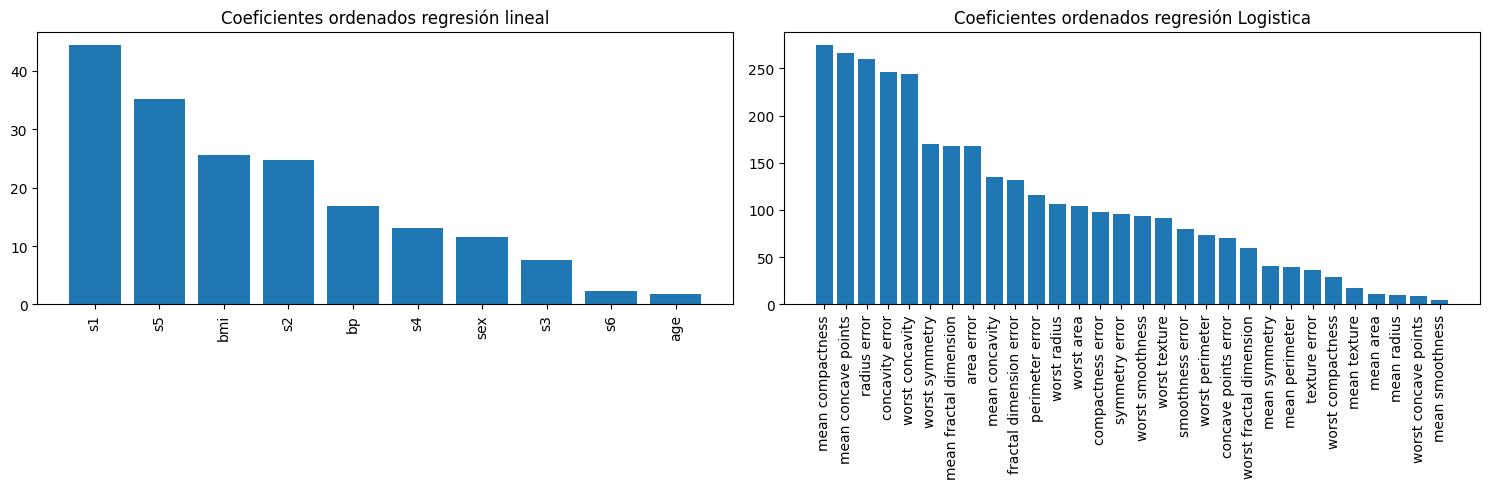

In [45]:
coef = lr.coef_
feature_names = np.array(load_diabetes().feature_names)
idx = np.argsort(np.abs(coef))[::-1]

plt.figure(figsize=(15,5))
plt.subplot(121)
plt.bar(range(len(coef)), np.abs(coef[idx]))
plt.xticks(range(len(coef)), feature_names[idx], rotation=90)
plt.title("Coeficientes ordenados regresión lineal")
plt.tight_layout()

coef = logreg.coef_.flatten()
feature_names = np.array(load_breast_cancer().feature_names)
idx = np.argsort(np.abs(coef))[::-1]

plt.subplot(122)
plt.bar(range(len(coef)), np.abs(coef[idx]))
plt.xticks(range(len(coef)), feature_names[idx], rotation=90)
plt.title("Coeficientes ordenados regresión Logistica")
plt.tight_layout()
plt.show()

**Paso 2: Aplicando Ridge (L2)**

In [4]:
# Ridge con un valor de lambda (alpha en scikit-learn) moderado
ridge = Ridge(alpha=1.0)  # alpha = lambda
ridge.fit(X_train_reg_scaled, y_train_reg)
y_pred_ridge = ridge.predict(X_test_reg_scaled)
mse_ridge = mean_squared_error(y_test_reg, y_pred_ridge)

print("--- RIDGE REGRESSION (alpha=1.0) ---")
print(f"Coeficientes (theta): {ridge.coef_}")
print(f"MSE en test: {mse_ridge:.2f}")
print("Observamos que los coeficientes son más pequeños que en regresión lineal.\n")

# Para clasificación, LogisticRegression con penalty='l2' (es el default)
logreg_l2 = LogisticRegression(penalty='l2', C=1.0, solver='lbfgs', max_iter=10000) # C es el inverso de lambda (C=1/lambda)
logreg_l2.fit(X_train_clf_scaled, y_train_clf)
y_pred_log_l2 = logreg_l2.predict(X_test_clf_scaled)
acc_log_l2 = accuracy_score(y_test_clf, y_pred_log_l2)

print("--- LOGISTIC REGRESSION L2 (C=1.0) ---")
print(f"Coeficientes (theta): {logreg_l2.coef_.flatten()}")
print(f"Accuracy en test: {acc_log_l2:.4f}\n")

--- RIDGE REGRESSION (alpha=1.0) ---
Coeficientes (theta): [  1.807 -11.448  25.733  16.734 -34.672  17.053   3.37   11.764  31.378
   2.458]
MSE en test: 2892.01
Observamos que los coeficientes son más pequeños que en regresión lineal.

--- LOGISTIC REGRESSION L2 (C=1.0) ---
Coeficientes (theta): [-0.432 -0.387 -0.393 -0.465 -0.072  0.54  -0.801 -1.12   0.236  0.076
 -1.268  0.189 -0.611 -0.907 -0.313  0.682  0.175 -0.311  0.5    0.616
 -0.88  -1.351 -0.589 -0.842 -0.544  0.016 -0.943 -0.778 -1.208 -0.157]
Accuracy en test: 0.9737



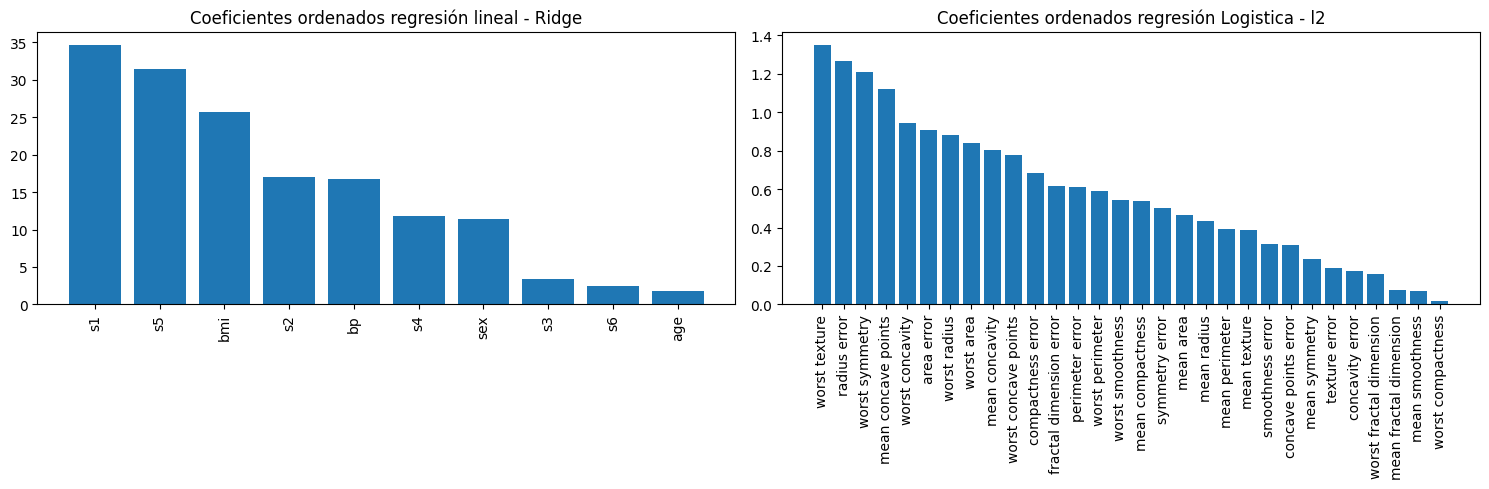

In [35]:

coef = ridge.coef_
feature_names = np.array(load_diabetes().feature_names)
idx = np.argsort(np.abs(coef))[::-1]

plt.figure(figsize=(15,5))
plt.subplot(121)
plt.bar(range(len(coef)), np.abs(coef[idx]))
plt.xticks(range(len(coef)), feature_names[idx], rotation=90)
plt.title("Coeficientes ordenados regresión lineal - Ridge")
plt.tight_layout()

coef = logreg_l2.coef_.flatten()
feature_names = np.array(load_breast_cancer().feature_names)
idx = np.argsort(np.abs(coef))[::-1]

plt.subplot(122)
plt.bar(range(len(coef)), np.abs(coef[idx]))
plt.xticks(range(len(coef)), feature_names[idx], rotation=90)
plt.title("Coeficientes ordenados regresión Logistica - l2")
plt.tight_layout()
plt.show()

**Paso 3: Aplicando Lasso (L1)**

In [5]:
# Lasso con alpha=0.1
lasso = Lasso(alpha=4, max_iter=10000)
lasso.fit(X_train_reg_scaled, y_train_reg)
y_pred_lasso = lasso.predict(X_test_reg_scaled)
mse_lasso = mean_squared_error(y_test_reg, y_pred_lasso)

print("--- LASSO REGRESSION (alpha=0.1) ---")
print(f"Coeficientes (theta): {lasso.coef_}")
print(f"MSE en test: {mse_lasso:.2f}")
print("Observamos que algunos coeficientes son exactamente 0.\n")

# Clasificación con L1
logreg_l1 = LogisticRegression(penalty='l1', C=1.0, solver='saga', max_iter=10000) # solver='saga' para L1
logreg_l1.fit(X_train_clf_scaled, y_train_clf)
y_pred_log_l1 = logreg_l1.predict(X_test_clf_scaled)
acc_log_l1 = accuracy_score(y_test_clf, y_pred_log_l1)

print("--- LOGISTIC REGRESSION L1 (C=1.0) ---")
print(f"Coeficientes (theta): {logreg_l1.coef_.flatten()}")
print(f"Accuracy en test: {acc_log_l1:.4f}\n")

--- LASSO REGRESSION (alpha=0.1) ---
Coeficientes (theta): [ 0.    -4.205 25.891 12.941 -0.    -0.    -9.623  0.    18.95   0.   ]
MSE en test: 2817.73
Observamos que algunos coeficientes son exactamente 0.

--- LOGISTIC REGRESSION L1 (C=1.0) ---
Coeficientes (theta): [ 0.     0.     0.     0.     0.     0.     0.    -2.196  0.053  0.
 -2.447  0.342  0.     0.    -0.459  0.834  0.     0.     0.461  0.343
 -2.086 -1.836  0.    -1.436 -0.108  0.    -1.282 -0.269 -1.016  0.   ]
Accuracy en test: 0.9649



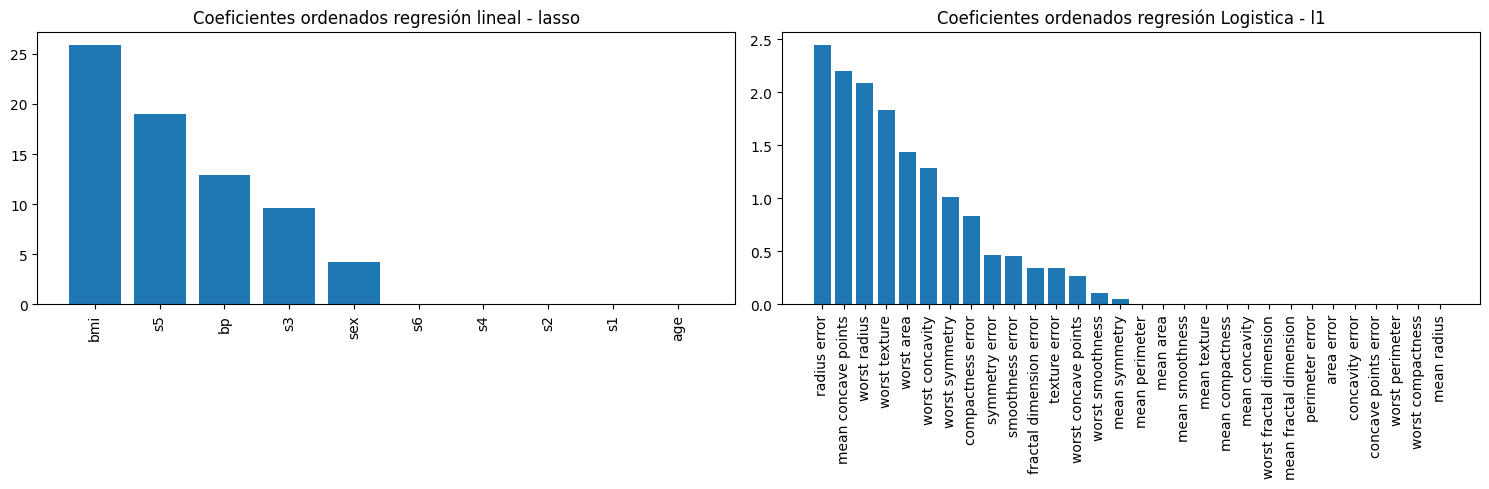

In [39]:

coef = lasso.coef_
feature_names = np.array(load_diabetes().feature_names)
idx = np.argsort(np.abs(coef))[::-1]

plt.figure(figsize=(15,5))
plt.subplot(121)
plt.bar(range(len(coef)), np.abs(coef[idx]))
plt.xticks(range(len(coef)), feature_names[idx], rotation=90)
plt.title("Coeficientes ordenados regresión lineal - lasso")
plt.tight_layout()

coef = logreg_l1.coef_.flatten()
feature_names = np.array(load_breast_cancer().feature_names)
idx = np.argsort(np.abs(coef))[::-1]

plt.subplot(122)
plt.bar(range(len(coef)), np.abs(coef[idx]))
plt.xticks(range(len(coef)), feature_names[idx], rotation=90)
plt.title("Coeficientes ordenados regresión Logistica - l1")
plt.tight_layout()
plt.show()

**Paso 4: Aplicando Elastic Net**


In [40]:
# ElasticNet con alpha=0.1 y l1_ratio=0.5 (mezcla 50% L1, 50% L2)
elastic = ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000)
elastic.fit(X_train_reg_scaled, y_train_reg)
y_pred_elastic = elastic.predict(X_test_reg_scaled)
mse_elastic = mean_squared_error(y_test_reg, y_pred_elastic)

print("--- ELASTIC NET (alpha=0.1, l1_ratio=0.5) ---")
print(f"Coeficientes (theta): {elastic.coef_}")
print(f"MSE en test: {mse_elastic:.2f}\n")

# Clasificación con Elastic Net
logreg_en = LogisticRegression(penalty='elasticnet', C=1.0, l1_ratio=0.5, solver='saga', max_iter=10000)
logreg_en.fit(X_train_clf_scaled, y_train_clf)
y_pred_log_en = logreg_en.predict(X_test_clf_scaled)
acc_log_en = accuracy_score(y_test_clf, y_pred_log_en)

print("--- LOGISTIC REGRESSION ELASTIC NET (C=1.0, l1_ratio=0.5) ---")
print(f"Coeficientes (theta): {logreg_en.coef_.flatten()}")
print(f"Accuracy en test: {acc_log_en:.4f}\n")

--- ELASTIC NET (alpha=0.1, l1_ratio=0.5) ---
Coeficientes (theta): [  1.902 -10.623  25.236  16.     -8.893  -2.079  -7.816   7.708  20.998
   3.152]
MSE en test: 2866.46

--- LOGISTIC REGRESSION ELASTIC NET (C=1.0, l1_ratio=0.5) ---
Coeficientes (theta): [-0.337 -0.271 -0.255 -0.356  0.     0.321 -0.603 -1.328  0.167  0.
 -1.521  0.195 -0.394 -0.88  -0.339  0.715  0.    -0.05   0.503  0.469
 -1.03  -1.452 -0.547 -0.919 -0.455  0.    -0.866 -0.801 -1.151  0.   ]
Accuracy en test: 0.9737



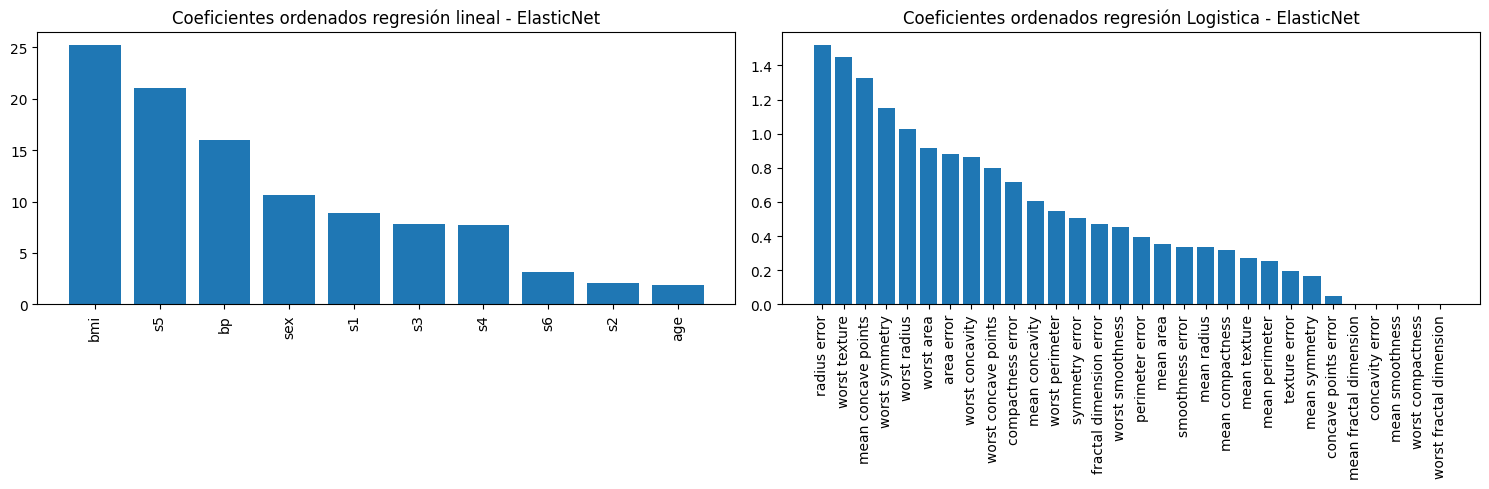

In [41]:
coef = elastic.coef_
feature_names = np.array(load_diabetes().feature_names)
idx = np.argsort(np.abs(coef))[::-1]

plt.figure(figsize=(15,5))
plt.subplot(121)
plt.bar(range(len(coef)), np.abs(coef[idx]))
plt.xticks(range(len(coef)), feature_names[idx], rotation=90)
plt.title("Coeficientes ordenados regresión lineal - ElasticNet")
plt.tight_layout()

coef = logreg_en.coef_.flatten()
feature_names = np.array(load_breast_cancer().feature_names)
idx = np.argsort(np.abs(coef))[::-1]

plt.subplot(122)
plt.bar(range(len(coef)), np.abs(coef[idx]))
plt.xticks(range(len(coef)), feature_names[idx], rotation=90)
plt.title("Coeficientes ordenados regresión Logistica - ElasticNet")
plt.tight_layout()
plt.show()

In [7]:
models_reg = {
    "Sin regularización":lr.coef_,
    "Ridge": ridge.coef_,
    "Lasso": lasso.coef_,
    "ElasticNet": elastic.coef_
}


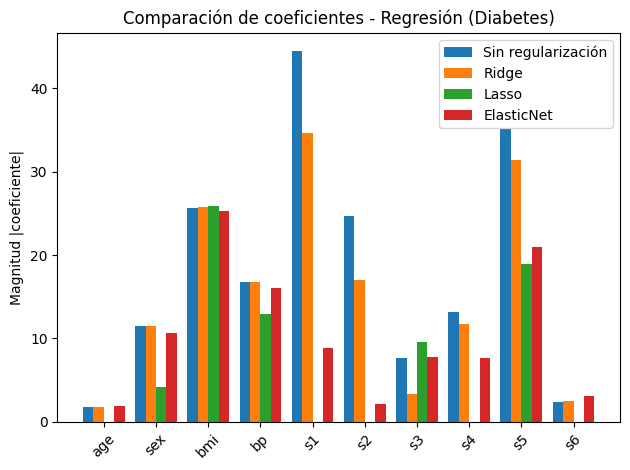

In [8]:
coef_dict = models_reg

# nombres de variables (diabetes tiene 10 features)
feature_names = load_diabetes().feature_names

x = np.arange(len(feature_names))
width = 0.2

plt.figure()
for i, (name, coef) in enumerate(coef_dict.items()):
    plt.bar(x + i*width, np.abs(coef), width, label=name)

plt.xticks(x + width*1.5, feature_names, rotation=45)
plt.ylabel("Magnitud |coeficiente|")
plt.title("Comparación de coeficientes - Regresión (Diabetes)")
plt.legend()
plt.tight_layout()
plt.show()

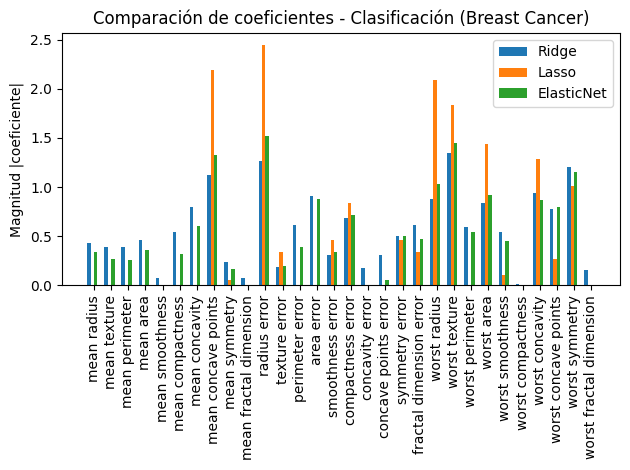

In [10]:
models_clf = {
    #"Sin regularización":logreg.coef_.flatten(),
    "Ridge": logreg_l2.coef_.flatten(),
    "Lasso": logreg_l1.coef_.flatten(),
    "ElasticNet": logreg_en.coef_.flatten()
}
# ===== CLASIFICACIÓN (breast cancer) =====
coef_dict = models_clf

feature_names = load_breast_cancer().feature_names

x = np.arange(len(feature_names))
width = 0.2

plt.figure()
for i, (name, coef) in enumerate(coef_dict.items()):
    plt.bar(x + i*width, np.abs(coef), width, label=name)

plt.xticks(x + width*1.5, feature_names, rotation=90)
plt.ylabel("Magnitud |coeficiente|")
plt.title("Comparación de coeficientes - Clasificación (Breast Cancer)")
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
mse_scores = {
    "Sin regularización": mse_lr,
    "Ridge": mse_ridge,
    "Lasso": mse_lasso,
    "ElasticNet": mse_elastic
}

acc_scores = {
    "Sin regularización": acc_log,
    "Ridge": acc_log_l2,
    "Lasso": acc_log_l1,
    "ElasticNet": acc_log_en
}

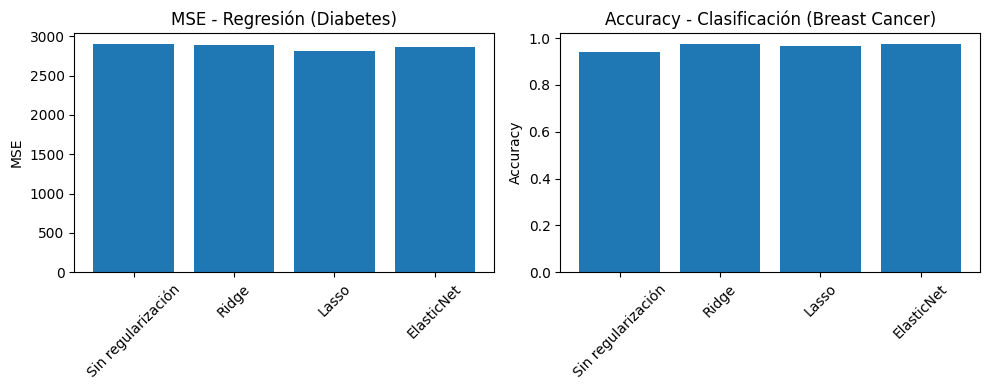

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(10,4))

# MSE
ax[0].bar(models, mse_values)
ax[0].set_title("MSE - Regresión (Diabetes)")
ax[0].set_ylabel("MSE")
ax[0].tick_params(axis='x', rotation=45)

# Accuracy
ax[1].bar(models, acc_values)
ax[1].set_title("Accuracy - Clasificación (Breast Cancer)")
ax[1].set_ylabel("Accuracy")
ax[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Paso 5: La clave del éxito: Encontrar el mejor λ (Validación Cruzada)**

No tenemos por qué adivinar el valor de `alpha` (λ). `scikit-learn` nos ofrece versiones con validación cruzada incorporada.


In [10]:
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import LassoCV
from sklearn.linear_model import ElasticNetCV
# Ridge con CV
ridge_cv = RidgeCV(alphas=np.logspace(-3, 3, 50), scoring='neg_mean_squared_error')
ridge_cv.fit(X_train_reg_scaled, y_train_reg)
print(f"Mejor alpha para Ridge: {ridge_cv.alpha_}")
print(f"MSE en test con RidgeCV: {mean_squared_error(y_test_reg, ridge_cv.predict(X_test_reg_scaled)):.2f}\n")

# Lasso con CV
lasso_cv = LassoCV(alphas=np.logspace(-3, 3, 50), cv=5, max_iter=10000)
lasso_cv.fit(X_train_reg_scaled, y_train_reg)
print(f"Mejor alpha para Lasso: {lasso_cv.alpha_}")
print(f"MSE en test con LassoCV: {mean_squared_error(y_test_reg, lasso_cv.predict(X_test_reg_scaled)):.2f}\n")

# ElasticNet con CV
elastic_cv = ElasticNetCV(alphas=np.logspace(-3, 3, 30), l1_ratio=[.1, .5, .7, .9, .95, .99, 1], cv=5, max_iter=10000)
elastic_cv.fit(X_train_reg_scaled, y_train_reg)
print(f"Mejor alpha para ElasticNet: {elastic_cv.alpha_}")
print(f"Mejor l1_ratio para ElasticNet: {elastic_cv.l1_ratio_}")
print(f"MSE en test con ElasticNetCV: {mean_squared_error(y_test_reg, elastic_cv.predict(X_test_reg_scaled)):.2f}")

Mejor alpha para Ridge: 1.151395399326447
MSE en test con RidgeCV: 2891.20

Mejor alpha para Lasso: 1.5264179671752334
MSE en test con LassoCV: 2801.69

Mejor alpha para ElasticNet: 0.11721022975334805
Mejor l1_ratio para ElasticNet: 0.1
MSE en test con ElasticNetCV: 2858.68



```python

```



```python

```



```python

```



```python

```


```python

```


```python

```

## 4. Interpretación y Conclusiones

Hemos visto cómo la regularización actúa como un "freno" para nuestro modelo lineal, evitando que se vuelva demasiado complejo y sobreajuste los datos.

*   **Ridge (L2)** es como un "estabilizador". Reduce la magnitud de todos los coeficientes, siendo muy útil cuando tenemos muchas características correlacionadas. Es la opción segura y robusta.
*   **Lasso (L1)** es como un "seleccionador". Además de reducir coeficientes, puede llevar algunos a cero, haciendo una selección automática de características. Ideal cuando sospechamos que solo algunas variables son realmente relevantes.
*   **Elastic Net** es el "todoterreno". Combina la selección de Lasso con la estabilidad de Ridge, especialmente poderoso cuando hay grupos de características correlacionadas.

En el mundo del negocio, estas herramientas nos permiten construir modelos más fiables e interpretables. Desde predecir el fraude (clasificación) hasta la demanda de un producto (regresión), la regularización es un paso indispensable en el flujo de trabajo de cualquier científico de datos.

**Recuerden siempre:**
1.  **Estandarizar** las características antes de aplicar regularización.
2.  Usar **validación cruzada** para elegir el mejor valor de $\lambda$ (alpha).
3.  Experimentar con los tres tipos y elegir el que mejor se adapte a su problema y datos.

